Python Notebook Showcase

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("drive/MyDrive/vgsales.csv")
df = df.dropna()
df["Year"] = df["Year"].astype(int)

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
print(f"{df.shape[0]:,} rows by {df.shape[1]} columns")
print(f"{df['Year'].max() - df["Year"].min()} years covered")
print(f"{df['Platform'].nunique()} platforms")
print(f"{df['Genre'].nunique()} genres")
print(f"{df['Publisher'].nunique()} publishers")

print("\nSales by Region (in Millions):")
df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].describe().round(2)

16,291 rows by 11 columns
40 years covered
31 platforms
12 genres
576 publishers

Sales by Region (in Millions):


,NA_Sales,EU_Sales,JP_Sales,Other_Sales
count,16291.00,16291.00,16291.00,16291.00
mean,0.27,0.15,0.08,0.05
std,0.82,0.51,0.31,0.19
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00
50%,0.08,0.02,0.00,0.01
75%,0.24,0.11,0.04,0.04
max,41.49,29.02,10.22,10.57


In [6]:
sales_by_genre = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
sales_by_genre.head(10)

,Global_Sales
Genre,
Action,1722.84
Sports,1309.24
Shooter,1026.20
Role-Playing,923.83
Platform,829.13
Misc,789.87
Racing,726.76
Fighting,444.05
Simulation,389.98


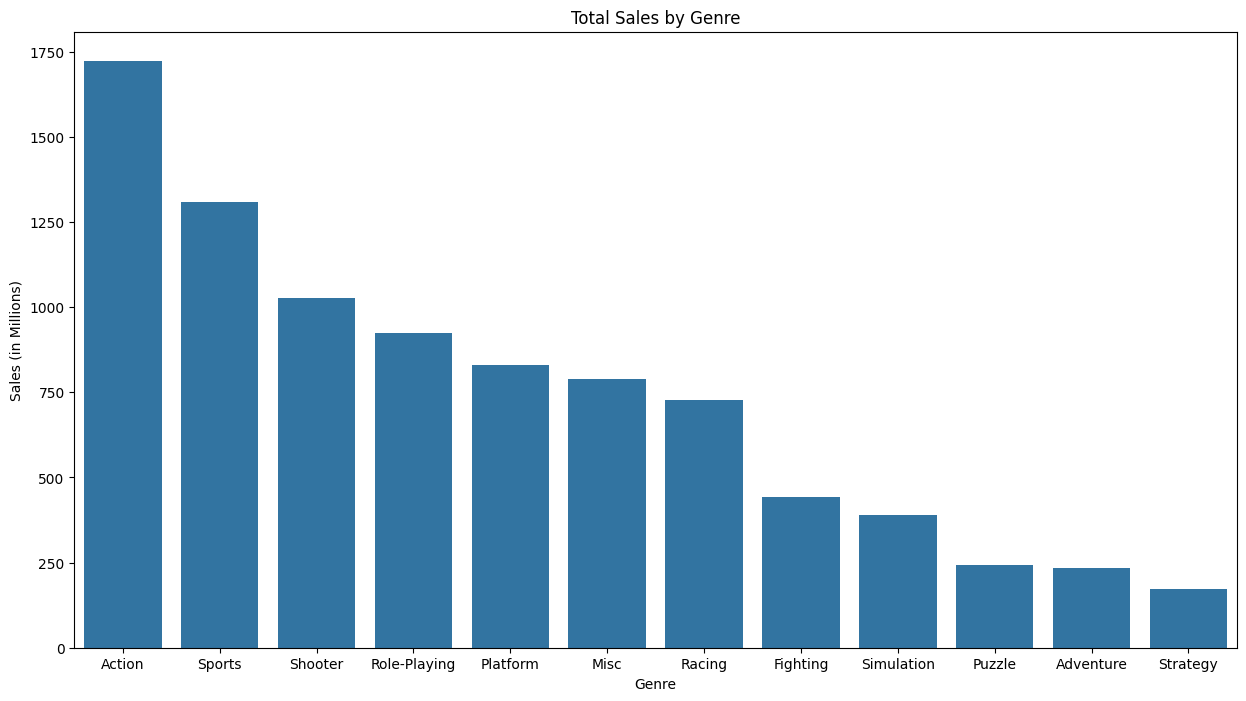

In [7]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(x=sales_by_genre.index, y=sales_by_genre.values, ax=ax)
ax.set_title("Total Sales by Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Sales (in Millions)")
plt.show()

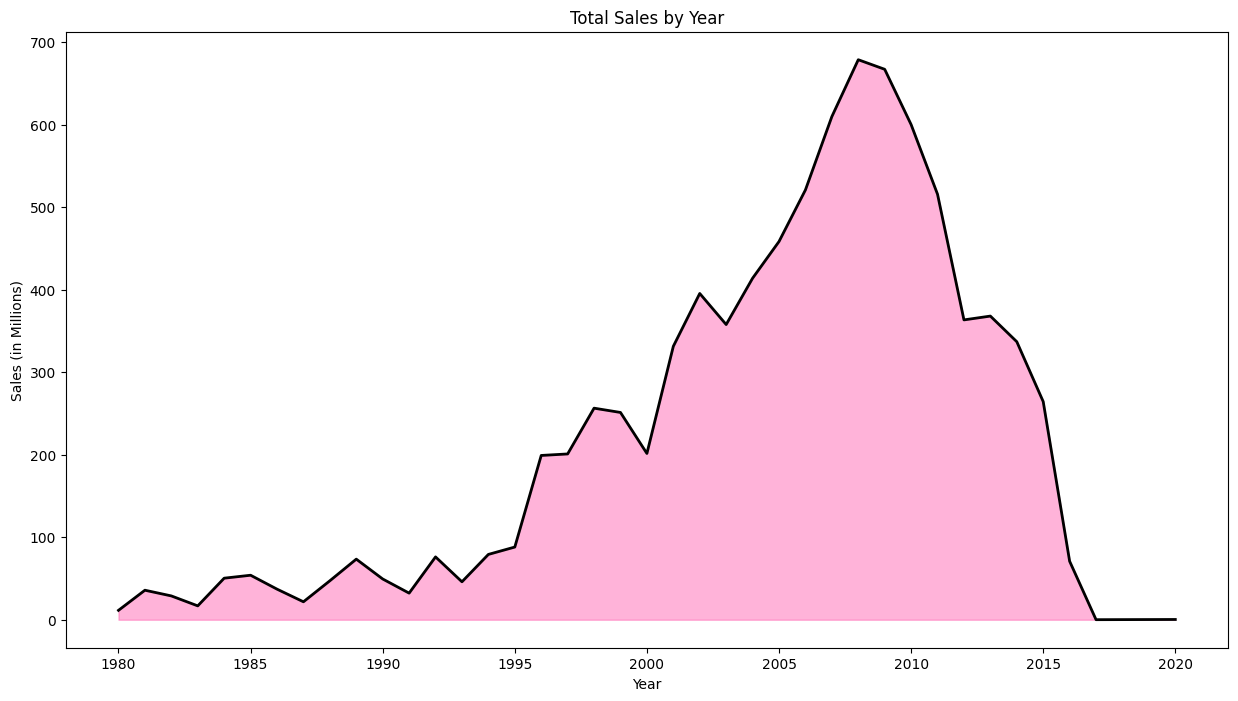

In [8]:
annual_sales = df[df['Year'].between(df['Year'].min(), df['Year'].max())].groupby('Year')["Global_Sales"].sum()

fig, ax = plt.subplots(figsize=(15, 8))
ax.fill_between(annual_sales.index, annual_sales.values, alpha=0.5, color = "hotpink")
ax.plot(annual_sales.index, annual_sales.values, color="black", linewidth = 2)
ax.set_title("Total Sales by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Sales (in Millions)")
plt.show()